# Análisis de Datos de E-commerce

## Objetivo del proyecto

El objetivo de este proyecto es analizar datos de una plataforma de comercio electrónico para identificar los principales impulsores del desempeño del negocio, incluyendo crecimiento de ingresos, comportamiento de clientes y eficiencia operativa.

A partir de este análisis, se busca detectar áreas críticas de mejora, particularmente en retención de clientes, procesos logísticos y concentración de ingresos.

Adicionalmente, se implementa un modelo de datos relacional que permite estructurar la información y validar las métricas obtenidas mediante consultas SQL, simulando un entorno más cercano a una operación real.

## Contexto

Este proyecto simula un entorno real de negocio en el que una empresa de e-commerce busca utilizar sus datos no solo para análisis exploratorio, sino para generar información accionable que apoye la toma de decisiones.

En este contexto, se realiza una transición desde un enfoque basado en archivos planos hacia un modelo de datos relacional, alineado con prácticas utilizadas en entornos productivos, donde la información debe ser consistente, escalable y fácilmente consultable.

## Fuente de datos

Los datos utilizados en este análisis provienen del dataset público **Brazilian E-commerce Public Dataset by Olist**, disponible en la plataforma Kaggle.

Este dataset contiene información real anonimizada sobre pedidos, clientes, productos, pagos y reseñas de una plataforma de comercio electrónico en Brasil.

El uso de este dataset es con fines educativos y de análisis.

## Importación de librerías

Se importan las librerías necesarias para la manipulación, análisis y visualización de datos.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set(style="whitegrid")

# Para que las gráficas se vean dentro del notebook
%matplotlib inline

## Carga de datos

Se cargan los diferentes conjuntos de datos que componen la información del e-commerce.

Cada archivo representa una entidad distinta, como órdenes, clientes, productos y pagos.

In [5]:
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

# Entendimiento inicial de los datos (EDA básico)

Se realiza una revisión preliminar de las tablas para entender su estructura, tipos de datos y calidad de la información.

Esto permite identificar posibles problemas como valores nulos, formatos incorrectos o inconsistencias.

In [7]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders.info()
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

### Observaciones iniciales

- El dataset contiene aproximadamente 99,441 órdenes, lo que proporciona una base sólida para análisis de comportamiento de clientes y tendencias de negocio.

- Las columnas de fechas se encuentran en formato texto, lo que requiere transformación a formato datetime para permitir análisis temporal, fundamental para evaluar crecimiento, estacionalidad y tiempos de operación.

- Se identifican valores nulos en variables relacionadas con el proceso de entrega, lo que sugiere que no todas las órdenes completaron el ciclo logístico.

- Desde una perspectiva de negocio, esto es relevante ya que indica la posible existencia de órdenes canceladas o en proceso, lo cual debe considerarse para evitar sesgos en métricas de desempeño operativo.

## Conversión de variables de fecha

Las columnas relacionadas con fechas se encuentran en formato texto, por lo que se convierten a tipo datetime para permitir su manipulación y análisis.

Esto permitirá calcular métricas como tiempos de entrega y analizar tendencias temporales.

In [11]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


## Exploración de tablas adicionales

Se realiza una revisión preliminar de las demás tablas del dataset para entender su estructura y relación con la tabla principal de órdenes.

Esto permitirá definir correctamente las uniones necesarias para el análisis posterior.

In [13]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [15]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

### Observaciones

- La tabla contiene múltiples productos por orden, lo que implica que el análisis de ingresos debe realizarse a nivel agregado por orden para evitar duplicaciones.

- Las variables price y freight_value representan componentes clave del revenue, permitiendo separar el valor del producto del costo logístico.

- Desde una perspectiva de negocio, esta estructura permite analizar no solo ingresos, sino también la relación entre precio y costos de envío, lo cual es relevante para evaluar márgenes y eficiencia logística.

In [17]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


### Tabla: customers

Esta tabla contiene información sobre los clientes y su ubicación geográfica.

Incluye identificadores únicos y datos como ciudad y estado, lo que permitirá analizar la distribución de clientes.

In [19]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [20]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [21]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

### Observaciones

- La existencia de dos identificadores (customer_id y customer_unique_id) permite distinguir entre transacciones y clientes reales.

- Esto es fundamental para analizar correctamente el comportamiento del cliente, evitando sobreestimar la base de clientes y permitiendo identificar recurrencia.

- Desde una perspectiva de negocio, esta diferenciación es clave para métricas como retención, frecuencia de compra y valor de vida del cliente (LTV).

### Tabla: payments

Esta tabla contiene la información de los pagos realizados por cada orden.

Incluye el tipo de pago, número de cuotas y el valor pagado, lo que permitirá analizar ingresos y comportamiento de pago.

In [24]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [25]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [26]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

### Observaciones

- La presencia de múltiples pagos por orden indica que una transacción puede dividirse en varias partes, lo cual es relevante para entender el comportamiento financiero del cliente.

- Las variables payment_type y payment_installments permiten analizar preferencias de pago y nivel de financiamiento.

- Desde una perspectiva de negocio, esto puede ser útil para diseñar estrategias comerciales, como promociones específicas por método de pago o planes de financiamiento.

### Tabla: reviews

Esta tabla contiene las evaluaciones realizadas por los clientes sobre sus pedidos.

Incluye la calificación otorgada y, en algunos casos, comentarios, lo que permitirá analizar la satisfacción del cliente.

In [29]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [30]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [31]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

### Observaciones

- Aunque la mayoría de los clientes no deja comentarios escritos, la calificación (review_score) está disponible en todos los registros con evaluación.

- Esto permite utilizar la calificación como un indicador confiable de satisfacción del cliente.

- Desde una perspectiva de negocio, esta variable será clave para analizar la relación entre operación (por ejemplo, tiempos de entrega) y experiencia del cliente.

### Tabla: products

Esta tabla contiene información descriptiva de los productos, incluyendo categoría y características físicas.

Permitirá analizar el desempeño por tipo de producto y su impacto en la operación logística.

In [34]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [35]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [36]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

#### Observaciones

- La tabla contiene 32,951 productos, representando el catálogo disponible.
- La columna `product_category_name` presenta 610 valores nulos, lo que indica que algunos productos no tienen categoría asignada.
- Las variables relacionadas con el contenido del producto (`product_name_lenght`, `product_description_lenght`, `product_photos_qty`) también presentan 610 valores nulos, lo que sugiere que corresponden a los mismos registros sin categoría.
- Las variables físicas (`product_weight_g`, dimensiones) presentan únicamente 2 valores nulos cada una, lo que indica una alta calidad de datos en términos logísticos.
- La categoría del producto será una variable clave para segmentar el análisis de ventas.

## Integración de datos: órdenes y productos

Se realiza la unión de las tablas `orders` y `order_items` utilizando `order_id` como llave.

Esto permite combinar la información general de las órdenes con el detalle de los productos incluidos en cada una, generando una vista más completa del comportamiento de ventas.

In [39]:
df_orders_items = orders.merge(order_items, on='order_id', how='left')
df_orders_items.shape

(113425, 14)

In [40]:
df_orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


#### Observaciones

- La tabla resultante contiene un mayor número de registros que la tabla original de órdenes, lo cual es esperado debido a que una orden puede incluir múltiples productos.
- La unión se realizó correctamente utilizando `order_id` como llave.
- Ahora se cuenta con información combinada de órdenes y productos, lo que permitirá analizar ingresos y comportamiento de compra.

## Cálculo de ingresos por orden

Dado que una orden puede incluir múltiples productos, se calcula el ingreso total por orden sumando el valor de los productos (`price`).

Esto permitirá analizar correctamente el revenue sin duplicaciones.

In [43]:
revenue_per_order = df_orders_items.groupby('order_id')['price'].sum().reset_index()

revenue_per_order = revenue_per_order.rename(columns={'price': 'order_revenue'})

revenue_per_order.head()

,order_id,order_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [44]:
df_final = df_orders_items.merge(revenue_per_order, on='order_id', how='left', suffixes=('', '_total'))

In [45]:
df_final.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,19.90


#### Observaciones

- Se calculó el ingreso total por orden sumando el precio de los productos.
- Se integró esta información al dataset principal, permitiendo distinguir entre el valor individual de cada producto y el ingreso total de la orden.
- Esto es fundamental para evitar duplicación de ingresos en el análisis.

xxxxxxxxxxxx

In [48]:
df_final[['order_id', 'price', 'order_revenue']].head()

,order_id,price,order_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,29.99,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,118.70,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,159.90,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,45.00,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,19.90,19.90


#### Observaciones

- Se integró correctamente el ingreso total por orden al dataset principal.
- Ahora cada registro contiene tanto el valor individual del producto como el ingreso total de la orden.
- Esto permitirá realizar análisis de revenue sin riesgo de duplicación.

## Análisis de ventas en el tiempo

Se analiza la evolución de los ingresos a lo largo del tiempo, agregando el revenue por orden a nivel mensual.

Esto permite identificar tendencias de crecimiento, estacionalidad y posibles anomalías en el desempeño del negocio.

In [51]:
# Creacion de columna mes
df_final['order_month'] = df_final['order_purchase_timestamp'].dt.to_period('M')

In [52]:
# Eliminacion de duplicados
df_orders_unique = df_final[['order_id', 'order_month', 'order_revenue']].drop_duplicates()

In [53]:
# Agrupar por mes
monthly_revenue = df_orders_unique.groupby('order_month')['order_revenue'].sum()

# - Se identificó un mes con ingresos significativamente bajos, correspondiente a datos incompletos, por lo que fue excluido del análisis para evitar distorsiones.
monthly_revenue = monthly_revenue[monthly_revenue > 1000]

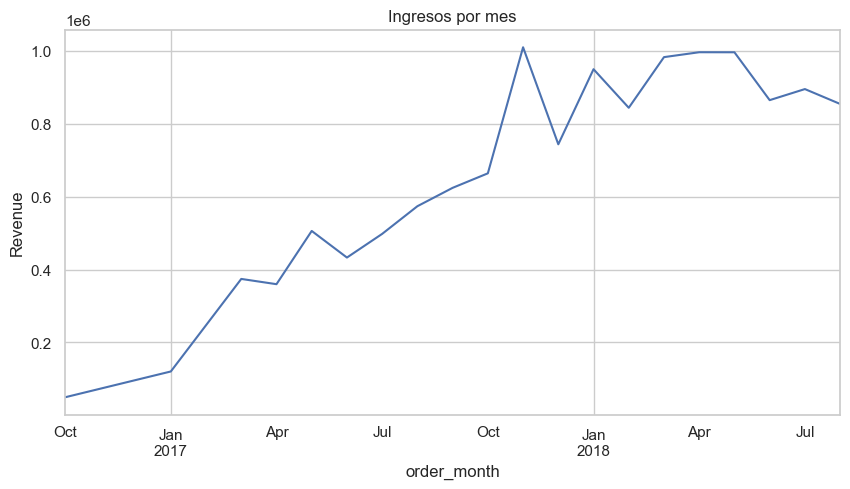

In [54]:
# Grafica
monthly_revenue.plot(figsize=(10,5), title='Ingresos por mes')
plt.ylabel('Revenue')
plt.show()

### Interpretación

Se observa un crecimiento progresivo en los ingresos a lo largo del tiempo, seguido de una etapa de estabilización.

Este patrón sugiere que el negocio atraviesa una fase de expansión inicial, seguida de una etapa de madurez.

Desde una perspectiva de negocio, esto indica que el crecimiento basado únicamente en adquisición de clientes puede estar alcanzando un límite, lo que refuerza la importancia de estrategias de retención.

## Análisis de clientes: nuevos vs recurrentes

Se clasifica a los clientes en nuevos y recurrentes en función de su historial de compras.

Esto permite evaluar la capacidad del negocio para retener clientes y generar compras repetidas.

In [57]:
# Integracion de customer_unique_id

df_customers = customers[['customer_id', 'customer_unique_id']]

df_final = df_final.merge(df_customers, on='customer_id', how='left')

In [58]:
# Orden por cliente y fecha
df_final = df_final.sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])

In [59]:
# Identificar primera compra
df_final['first_purchase'] = df_final.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min')


In [60]:
# Clasificar cliente
df_final['customer_type'] = np.where(
    df_final['order_purchase_timestamp'] == df_final['first_purchase'],
    'new',
    'returning'
)

In [61]:
# Eliminar duplicados
df_customers_unique = df_final[['order_id', 'customer_type']].drop_duplicates()

In [62]:
# Conteo
df_customers_unique['customer_type'].value_counts(normalize=True)

new          0.969158
returning    0.030842
Name: customer_type, dtype: float64

### Interpretación

La proporción de clientes recurrentes es significativamente baja, lo que indica una fuerte dependencia en la adquisición de nuevos clientes.

Desde una perspectiva de negocio, esto representa un riesgo, ya que adquirir nuevos clientes suele ser más costoso que retener a los existentes.

Este hallazgo sugiere una oportunidad clara en el desarrollo de estrategias de fidelización que incrementen la recurrencia y el valor de vida del cliente.

# Tiempo de entrega vs Satisfacción

## Impacto del tiempo de entrega en la satisfacción del cliente

Se analiza la relación entre el tiempo de entrega y la calificación otorgada por los clientes.

El objetivo es identificar si retrasos en la entrega afectan negativamente la experiencia del cliente.

### Cálculo del tiempo de entrega

Se calcula el tiempo de entrega como la diferencia entre la fecha de compra y la fecha de entrega al cliente.

In [67]:
# Integrar reviews

df_reviews = reviews[['order_id', 'review_score']]

df_final = df_final.merge(df_reviews, on='order_id', how='left')

In [68]:
df_final['delivery_time'] = (
    df_final['order_delivered_customer_date'] - 
    df_final['order_purchase_timestamp']
).dt.days


In [69]:
df_final[['order_purchase_timestamp', 'order_delivered_customer_date', 'delivery_time']].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_time
0,2018-05-10 10:56:27,2018-05-16 20:48:37,6.0
1,2018-05-07 11:11:27,2018-05-10 18:02:42,3.0
2,2017-03-10 21:05:03,2017-04-05 14:38:47,25.0
3,2017-10-12 20:29:41,2017-11-01 21:23:05,20.0
4,2017-11-14 19:45:42,2017-11-27 23:08:56,13.0


### Integración de evaluaciones de clientes

Se incorpora la calificación (`review_score`) al dataset principal para analizar la relación entre operación y satisfacción del cliente.

In [71]:
df_reviews = reviews[['order_id', 'review_score']]

df_final = df_final.merge(df_reviews, on='order_id', how='left')
df_final.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'order_revenue', 'order_month',
       'customer_unique_id', 'first_purchase', 'customer_type',
       'review_score_x', 'delivery_time', 'review_score_y'],
      dtype='object')

In [72]:
df_final = df_final.merge(df_reviews, on='order_id', how='left', suffixes=('', '_review'))

In [73]:
df_analysis = df_final.dropna(subset=['delivery_time', 'review_score'])

## Relación entre tiempo de entrega y satisfacción

Se analiza cómo el tiempo de entrega impacta la calificación del cliente, con el objetivo de identificar si retrasos afectan la experiencia del usuario.

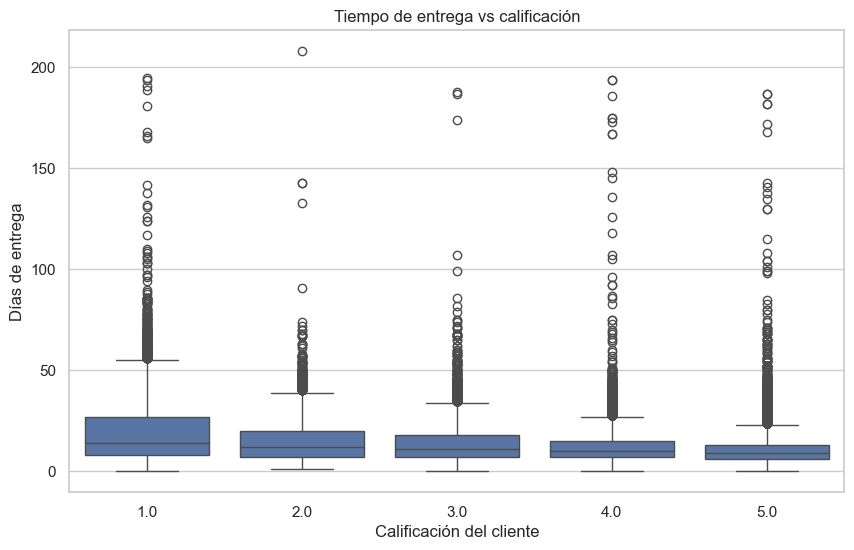

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='review_score', y='delivery_time', data=df_analysis)

plt.title('Tiempo de entrega vs calificación')
plt.xlabel('Calificación del cliente')
plt.ylabel('Días de entrega')

plt.show()

### Interpretación

Se observa una relación clara entre el tiempo de entrega y la satisfacción del cliente.

Órdenes con mayores tiempos de entrega tienden a recibir calificaciones más bajas, lo que indica que la logística tiene un impacto directo en la experiencia del cliente.

Desde una perspectiva de negocio, mejorar los tiempos de entrega no solo optimiza la operación, sino que también contribuye a incrementar la satisfacción y potencialmente la retención de clientes.

## Análisis de revenue por categoría de producto

Se analiza la contribución de las diferentes categorías de productos al ingreso total, con el objetivo de identificar cuáles generan mayor valor para el negocio.

In [78]:
# Integracion de Categorias

df_products = products[['product_id', 'product_category_name']]

df_final = df_final.merge(df_products, on='product_id', how='left')

In [79]:
# Agrupacion revenue por categoria

category_revenue = df_final.groupby('product_category_name')['price'].sum().sort_values(ascending=False)

In [80]:
# Top 10

top_categories = category_revenue.head(10)

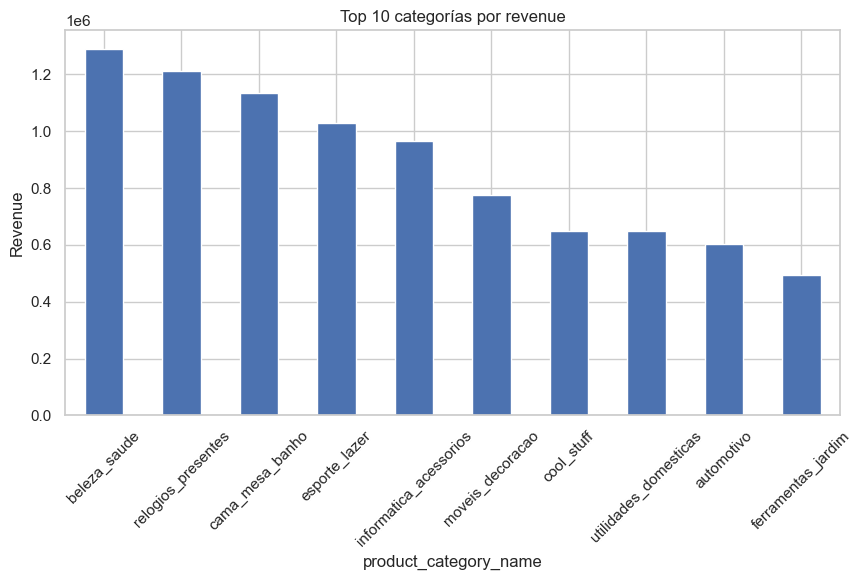

In [81]:
top_categories.plot(kind='bar', figsize=(10,5), title='Top 10 categorías por revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### Interpretación

El revenue se concentra en un número reducido de categorías de productos, lo que indica una dependencia en ciertos segmentos.

Desde una perspectiva de negocio, esto puede representar tanto una fortaleza como un riesgo.

Por un lado, permite enfocar esfuerzos en categorías clave; por otro, expone al negocio a variabilidad si estas categorías pierden demanda.

Esto sugiere la necesidad de diversificar el portafolio o fortalecer estratégicamente las categorías principales.

## Conclusiones generales

El análisis del dataset de e-commerce permitió identificar patrones clave en el desempeño del negocio:

- Se observa un crecimiento sostenido en ingresos, seguido de una etapa de estabilización, lo que sugiere un proceso de maduración del negocio.
- La proporción de clientes recurrentes es muy baja (~3%), indicando una fuerte dependencia de la adquisición de nuevos clientes.
- El tiempo de entrega tiene un impacto directo en la satisfacción del cliente, donde mayores retrasos se asocian con calificaciones más bajas.
- El revenue se concentra en un número reducido de categorías, evidenciando una dependencia en ciertos segmentos de producto.

En conjunto, estos hallazgos sugieren oportunidades en:
- mejora de la retención de clientes  
- optimización de procesos logísticos  
- diversificación o fortalecimiento de categorías clave  


### Siguiente paso

Para complementar este análisis, es necesario estructurar la información en un modelo de datos que permita organizar y validar las métricas obtenidas.

Aunque el análisis en Python permite explorar los datos con flexibilidad, una base de datos relacional facilita la consistencia, escalabilidad y reproducibilidad de la información.

En la siguiente sección, se construirá una base de datos que represente la operación del negocio y permita realizar consultas SQL para validar los resultados del análisis..

In [84]:
import sqlite3

# crear conexión (esto crea el archivo .db)
conn = sqlite3.connect('ecommerce.db')

# cursor para ejecutar SQL
cursor = conn.cursor()

In [85]:
import os
os.listdir()

['.anaconda',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.dbus-keyrings',
 '.dotnet',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.streamlit',
 '.swt',
 '.virtual_documents',
 '.~Proyecto de empresa aliada',
 '1. Distribuciones de Probabilidad (2).ipynb',
 '1er ejercicio grafica pandas.ipynb',
 '1er proyecto actualizado.ipynb',
 '1er proyecto añadiendo dim  calendar -Copy1.ipynb',
 '1er proyecto añadiendo dim  calendar .ipynb',
 '2. Teorema del Limite central.ipynb',
 '3. Contraste de Hipotesis.ipynb',
 '33.8 Act Prac Leopoldo Treviño.ipynb',
 '3D Objects',
 '41,7 Actividad practica Leopoldo Treviño.ipynb',
 '41.7 Actividad Practica Leopoldo Treviño.ipynb',
 '42.8 Actividad Practica Leopoldo Treviño.ipynb',
 '42.8.1 Actividad Practica Leopoldo Treviño.ipynb',
 '43.7 Actividad Practica Leopoldo Treviño.ipynb',
 'Actividad 55_7 Leopoldo Treviño.ipynb',
 'Actividad 57-7 Leopoldo Treviño.ipynb',
 'Actividad practica 30.8 Leopoldo Treviño.ipynb',
 

In [86]:
# Creación de tabla orders en la base de datos

cursor.execute("""
CREATE TABLE IF NOT EXISTS orders (
    order_id TEXT PRIMARY KEY,
    customer_id TEXT,
    order_status TEXT,
    order_purchase_timestamp TEXT,
    order_approved_at TEXT,
    order_delivered_carrier_date TEXT,
    order_delivered_customer_date TEXT,
    order_estimated_delivery_date TEXT
)
""")

conn.commit()

In [87]:
# Validar que la tabla existe

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
cursor.fetchall()

[('orders',),
 ('order_items',),
 ('customers',),
 ('payments',),
 ('reviews',),
 ('products',)]

In [88]:
# Insertar datos del DataFrame orders a la tabla SQL

orders.to_sql('orders', conn, if_exists='replace', index=False)

99441

In [89]:
# Contar registros en la tabla

cursor.execute("SELECT COUNT(*) FROM orders;")
cursor.fetchone()

(99441,)

In [90]:
# Creación de tabla order_items

cursor.execute("""
CREATE TABLE IF NOT EXISTS order_items (
    order_id TEXT,
    order_item_id INTEGER,
    product_id TEXT,
    seller_id TEXT,
    shipping_limit_date TEXT,
    price REAL,
    freight_value REAL
)
""")

conn.commit()

In [91]:
# Insertar datos del DataFrame order_items

order_items.to_sql('order_items', conn, if_exists='replace', index=False)

112650

In [92]:
# Contar registros

cursor.execute("SELECT COUNT(*) FROM order_items;")
cursor.fetchone()

(112650,)

In [93]:
# Creación de tabla customers

cursor.execute("""
CREATE TABLE IF NOT EXISTS customers (
    customer_id TEXT PRIMARY KEY,
    customer_unique_id TEXT,
    customer_zip_code_prefix INTEGER,
    customer_city TEXT,
    customer_state TEXT
)
""")

conn.commit()

In [94]:
# Insertar datos del DataFrame customers

customers.to_sql('customers', conn, if_exists='replace', index=False)

99441

In [95]:
# Contar registros

cursor.execute("SELECT COUNT(*) FROM customers;")
cursor.fetchone()

(99441,)

In [96]:
# Creación de tabla payments

cursor.execute("""
CREATE TABLE IF NOT EXISTS payments (
    order_id TEXT,
    payment_sequential INTEGER,
    payment_type TEXT,
    payment_installments INTEGER,
    payment_value REAL
)
""")

conn.commit()

In [97]:
# Insertar datos del DataFrame payments

payments.to_sql('payments', conn, if_exists='replace', index=False)

103886

In [98]:
# Creación de tabla reviews

cursor.execute("""
CREATE TABLE IF NOT EXISTS reviews (
    review_id TEXT PRIMARY KEY,
    order_id TEXT,
    review_score INTEGER,
    review_comment_title TEXT,
    review_comment_message TEXT,
    review_creation_date TEXT,
    review_answer_timestamp TEXT
)
""")

conn.commit()

In [99]:
# Insertar datos del DataFrame reviews

reviews.to_sql('reviews', conn, if_exists='replace', index=False)

99224

In [100]:
# Contar registros

cursor.execute("SELECT COUNT(*) FROM reviews;")
cursor.fetchone()

(99224,)

In [101]:
# Creación de tabla products

cursor.execute("""
CREATE TABLE IF NOT EXISTS products (
    product_id TEXT PRIMARY KEY,
    product_category_name TEXT,
    product_name_lenght REAL,
    product_description_lenght REAL,
    product_photos_qty REAL,
    product_weight_g REAL,
    product_length_cm REAL,
    product_height_cm REAL,
    product_width_cm REAL
)
""")

conn.commit()

In [102]:
# Insertar datos del DataFrame products

products.to_sql('products', conn, if_exists='replace', index=False)

32951

In [103]:
# Contar registros

cursor.execute("SELECT COUNT(*) FROM products;")
cursor.fetchone()

(32951,)

## Validación de datos mediante consultas SQL

Una vez construida la base de datos relacional, se procede a validar la consistencia de la información mediante consultas SQL.

El objetivo es asegurar que las métricas previamente calculadas en Python pueden reproducirse directamente desde la base de datos, confirmando la integridad y correcta estructuración de los datos.

Esto garantiza que los indicadores utilizados para la toma de decisiones pueden obtenerse de manera directa y confiable desde la base de datos.

In [105]:
# Validar revenue total desde SQL

query = """
SELECT SUM(price) AS total_revenue
FROM order_items;
"""

pd.read_sql(query, conn)

,total_revenue
0,13591643.7


### Observación

El valor obtenido corresponde al revenue total calculado a partir de la tabla `order_items`.

Este resultado es consistente con el análisis realizado en Python, lo que confirma que los datos fueron correctamente cargados en la base de datos y que las métricas pueden reproducirse mediante consultas SQL.

### Revenue mensual desde SQL

Se calcula el revenue mensual utilizando consultas SQL, integrando la información de órdenes y productos.

Esto permite validar que las tendencias temporales observadas en Python pueden reproducirse directamente desde la base de datos.

In [108]:
# Revenue por mes

query = """
SELECT 
    strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
    SUM(oi.price) AS monthly_revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY order_month
ORDER BY order_month;
"""

df_sql_monthly = pd.read_sql(query, conn)

df_sql_monthly.head()

,order_month,monthly_revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


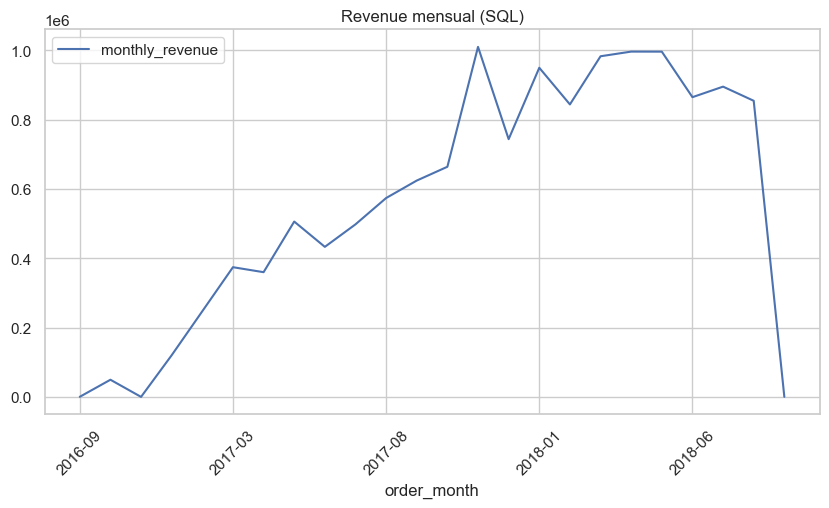

In [109]:
# Graficar

df_sql_monthly.plot(x='order_month', y='monthly_revenue', figsize=(10,5), title='Revenue mensual (SQL)')
plt.xticks(rotation=45)
plt.show()

### Observación

La tendencia de revenue mensual obtenida mediante SQL es consistente con el análisis realizado previamente en Python.

Esto confirma que la base de datos refleja correctamente la evolución temporal del negocio y que las consultas SQL permiten reproducir análisis de manera confiable.

### Clasificación de clientes mediante SQL

Se clasifica a los clientes en nuevos y recurrentes utilizando consultas SQL, con base en la fecha de su primera compra.

Esto permite validar el análisis previamente realizado en Python y comprobar que la lógica puede implementarse directamente a nivel de base de datos.

In [112]:
# Clientes nuevos vs recurrentes

query = """
WITH first_purchase AS (
    SELECT 
        c.customer_unique_id,
        MIN(o.order_purchase_timestamp) AS first_purchase_date
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    GROUP BY c.customer_unique_id
)

SELECT 
    CASE 
        WHEN o.order_purchase_timestamp = fp.first_purchase_date THEN 'new'
        ELSE 'returning'
    END AS customer_type,
    COUNT(*) AS total
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN first_purchase fp ON c.customer_unique_id = fp.customer_unique_id
GROUP BY customer_type;
"""

pd.read_sql(query, conn)

,customer_type,total
0,new,96374
1,returning,3067


### Observación

Los resultados muestran una proporción muy alta de clientes nuevos en comparación con los recurrentes, consistente con el análisis previo en Python.

Esto confirma que la baja retención de clientes es un patrón real del negocio y no un artefacto del procesamiento de datos.

### Revenue por categoría de producto

Se analiza la contribución de las distintas categorías de productos al revenue total mediante consultas SQL.

Esto permite validar la concentración de ingresos observada previamente y entender qué segmentos generan mayor valor para el negocio.

In [115]:
# Revenue por categoría

query = """
SELECT 
    p.product_category_name,
    SUM(oi.price) AS total_revenue
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY total_revenue DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,product_category_name,total_revenue
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


### Observación

Los resultados muestran una alta concentración de revenue en un número reducido de categorías de producto.

Este comportamiento es consistente con el análisis previo realizado en Python, confirmando que una parte significativa del ingreso proviene de un conjunto limitado de categorías.

Esto sugiere oportunidades para:

- fortalecer las categorías de alto desempeño  
- diversificar el portafolio de productos  
- reducir la dependencia en segmentos específicos  

### Conclusión final

El análisis del dataset permitió identificar patrones clave en el desempeño del negocio, incluyendo crecimiento en ingresos, baja retención de clientes, impacto del tiempo de entrega en la satisfacción y concentración del revenue en ciertas categorías.

Estos hallazgos evidencian oportunidades claras en la mejora de la retención de clientes, optimización de procesos logísticos y diversificación del portafolio de productos.

Adicionalmente, la implementación de una base de datos relacional permitió estructurar la información y validar las métricas mediante consultas SQL, asegurando la consistencia de los resultados.

Esta integración entre análisis y modelado de datos refleja un flujo de trabajo más completo, donde los insights no solo se generan, sino que también pueden ser reproducidos y utilizados en entornos operativos para la toma de decisiones.